In [1]:
import os
import ast
import wfdb
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, f1_score  # ADDED f1_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("CNN-TRANSFORMER HYBRID MODEL FOR ECG CLASSIFICATION")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

CNN-TRANSFORMER HYBRID MODEL FOR ECG CLASSIFICATION
PyTorch version: 2.5.1+cu121
CUDA available: True


In [5]:
# CONFIGURATION 
 
class Config:
    # Paths
    DATASET_PATH = Path("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3")
    
    # Training - OPTIMIZED
    BATCH_SIZE = 32
    EPOCHS = 150  # More epochs for convergence
    LR_MAX = 5e-4  # Lower max LR for stability
    LR_MIN = 1e-7
    WARMUP_EPOCHS = 10  # Longer warmup
    WEIGHT_DECAY = 5e-5  # Regularization
    
    # Model - DEEPER & BETTER
    CNN_CHANNELS = [64, 128, 256, 512, 512]  # 5 blocks instead of 4
    TRANSFORMER_LAYERS = 8  # More transformer layers
    NUM_HEADS = 8
    DIM_FEEDFORWARD = 2048  # Larger FFN
    DROPOUT = 0.15  # Lower dropout
    
    # Augmentation - STRONGER
    AUG_PROB = 0.8  # Higher augmentation probability
    MIXUP_ALPHA = 0.3  # Stronger mixup
    CUTOUT_PROB = 0.3  # Add cutout augmentation
    
    # Advanced Training
    LABEL_SMOOTHING = 0.05  # Lower smoothing
    GRADIENT_CLIP = 1.0
    USE_SAM = False  # Sharpness Aware Minimization (optional)
    
    # Test-Time Augmentation
    USE_TTA = True
    TTA_ITERATIONS = 7  # More TTA iterations
    
    # Class weighting
    USE_CLASS_WEIGHTS = True
    FOCAL_GAMMA = 2.5  # Stronger focal loss
    FOCAL_ALPHA = 0.3

In [4]:
import wandb

wandb.init(
    project="Hybrid-CNN-Transformer-ECG-notebooks_individual_notebooks",
    name="Hybrid-CNN-Transformer"
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: sdhakal13 (sdhakal13-youngstown-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:
# DATA LOADING - FIXED
# Load metadata
df = pd.read_csv(Config.DATASET_PATH / 'ptbxl_database.csv', index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(ast.literal_eval)

# Load SCP statements
agg_df = pd.read_csv(Config.DATASET_PATH / 'scp_statements.csv', index_col=0)

# Target labels
target_labels = ['NORM', 'AFIB', 'PVC', 'LVH', 'IMI', 'ASMI', 'LAFB', 'IRBBB']

# Build label matrix
def get_labels(scp_codes):
    labels = np.zeros(len(target_labels), dtype=np.float32)
    for code, confidence in scp_codes.items():
        if code in target_labels and confidence >= 50:  # confidence threshold
            labels[target_labels.index(code)] = 1.0
    return labels
 
df['labels'] = df.scp_codes.apply(get_labels)
 
# Keep only samples with at least one label
df = df[df['labels'].apply(lambda x: x.sum() > 0)].reset_index(drop=False)  # FIXED: keep index

# AUTO-DETECT FILENAME COLUMN (FIXED)
if 'filename_hr' in df.columns:
    filename_col = 'filename_hr'
elif 'filename' in df.columns:
    filename_col = 'filename'
elif 'filename_lr' in df.columns:
    filename_col = 'filename_lr'
else:
    raise ValueError(f"No filename column found! Columns: {df.columns.tolist()}")

print(f"✓ Using column: {filename_col}")

# Stratified split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
 
y_all = np.stack(df['labels'].values)
X_indices = df.index.values
 
# Train/Val/Test: 70/10/20
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(msss.split(X_indices, y_all))
 
X_temp = X_indices[temp_idx]
y_temp = y_all[temp_idx]
 
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.67, random_state=42)  # 0.67 of 0.3 = 0.2
val_idx, test_idx = next(msss2.split(X_temp, y_temp))
 
# FIXED: Use detected filename column
X_train = df.iloc[train_idx][filename_col].values
y_train = y_all[train_idx]
 
X_val = df.iloc[temp_idx[val_idx]][filename_col].values
y_val = y_temp[val_idx]
 
X_test = df.iloc[temp_idx[test_idx]][filename_col].values
y_test = y_temp[test_idx]
 
print(f"\nDataset split:")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Class distribution (train):")
for i, label in enumerate(target_labels):
    print(f"  {label}: {y_train[:, i].sum():.0f} ({100*y_train[:, i].mean():.1f}%)")

✓ Using column: filename_hr

Dataset split:
Train: 11324 | Val: 1602 | Test: 3216
Class distribution (train):
  NORM: 6606 (58.3%)
  AFIB: 34 (0.3%)
  PVC: 719 (6.3%)
  LVH: 1226 (10.8%)
  IMI: 1200 (10.6%)
  ASMI: 1405 (12.4%)
  LAFB: 1135 (10.0%)
  IRBBB: 780 (6.9%)


In [7]:
#Advanced Augmentation
class AdvancedAugmentation:
    """Stronger augmentation for better generalization"""
    def __init__(self, prob=0.8):
        self.prob = prob
    
    def __call__(self, signal):
        if np.random.random() > self.prob:
            return signal
        
        # 1. Amplitude scaling (±20%)
        if np.random.random() < 0.7:
            scale = np.random.uniform(0.8, 1.2)
            signal = signal * scale
        
        # 2. Temporal shift (±100 samples)
        if np.random.random() < 0.6:
            shift = np.random.randint(-100, 100)
            signal = np.roll(signal, shift, axis=1)
        
        # 3. Gaussian noise
        if np.random.random() < 0.5:
            noise = np.random.normal(0, 0.03, signal.shape)
            signal = signal + noise
        
        # 4. Baseline wander
        if np.random.random() < 0.4:
            freq = np.random.uniform(0.5, 2.0)
            t = np.linspace(0, 1, signal.shape[1])
            wander = 0.05 * np.sin(2 * np.pi * freq * t)
            signal = signal + wander
        
        # 5. Cutout (zero out random segments)
        if np.random.random() < Config.CUTOUT_PROB:
            cutout_len = np.random.randint(30, 100)
            start = np.random.randint(0, signal.shape[1] - cutout_len)
            signal[:, start:start+cutout_len] = 0
        
        # 6. Lead dropout (randomly zero out one lead)
        if np.random.random() < 0.3:
            lead_to_drop = np.random.randint(0, signal.shape[0])
            signal[lead_to_drop, :] = 0
        
        return signal


def load_ecg_normalized(record_path):
    """Load and normalize ECG"""
    try:
        record = wfdb.rdrecord(record_path)
        signal = record.p_signal.T  # (12, 1000)
        
        # Per-lead standardization
        mean = signal.mean(axis=1, keepdims=True)
        std = signal.std(axis=1, keepdims=True) + 1e-8
        signal = (signal - mean) / std
        
        return signal.astype(np.float32)
    except:
        return np.zeros((12, 1000), dtype=np.float32)


class PTBXL_Dataset(Dataset):
    def __init__(self, filenames, labels, base_path, augment=False):
        self.filenames = filenames
        self.labels = labels
        self.base_path = base_path
        self.augment = augment
        self.aug = AdvancedAugmentation(prob=Config.AUG_PROB)
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        record_path = str(self.base_path / self.filenames[idx])
        signal = load_ecg_normalized(record_path)
        
        if self.augment:
            signal = self.aug(signal)
        
        signal = torch.tensor(signal, dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        return signal, label

In [8]:
# Create datasets
train_dataset = PTBXL_Dataset(X_train, y_train, Config.DATASET_PATH, augment=True)
val_dataset = PTBXL_Dataset(X_val, y_val, Config.DATASET_PATH, augment=False)
test_dataset = PTBXL_Dataset(X_test, y_test, Config.DATASET_PATH, augment=False)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [9]:
#Hybrid model architecture
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block for channel attention"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool1d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1)
        return x * y.expand_as(x)
 
 
class ResidualCNNBlock(nn.Module):
    """Enhanced CNN block with SE attention"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.conv3 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm1d(out_channels)
        
        # SE attention
        self.se = SEBlock(out_channels)
        
        # Shortcut
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(Config.DROPOUT)
    
    def forward(self, x):
        identity = self.shortcut(x)
        
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        
        out = self.se(out)  # Attention
        out = out + identity  # Residual
        out = F.relu(out)
        out = self.pool(out)
        out = self.dropout(out)
        
        return out
 
 
class PositionalEncoding(nn.Module):
    """Positional encoding for transformer"""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:x.size(0), :]
 
 
class OptimizedHybrid(nn.Module):
    """SOTA Hybrid CNN-Transformer for 99% accuracy"""
    def __init__(self, input_channels=12, num_classes=8, 
                 cnn_channels=[64, 128, 256, 512, 512],
                 transformer_layers=8, num_heads=8, dropout=0.15):
        super().__init__()
        
        # CNN Encoder (5 blocks)
        self.cnn1 = ResidualCNNBlock(input_channels, cnn_channels[0])  # 12 -> 64, 1000 -> 500
        self.cnn2 = ResidualCNNBlock(cnn_channels[0], cnn_channels[1])  # 64 -> 128, 500 -> 250
        self.cnn3 = ResidualCNNBlock(cnn_channels[1], cnn_channels[2])  # 128 -> 256, 250 -> 125
        self.cnn4 = ResidualCNNBlock(cnn_channels[2], cnn_channels[3])  # 256 -> 512, 125 -> 62
        self.cnn5 = ResidualCNNBlock(cnn_channels[3], cnn_channels[4])  # 512 -> 512, 62 -> 31
        
        d_model = cnn_channels[-1]  # 512
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=Config.DIM_FEEDFORWARD,
            dropout=dropout,
            activation='gelu',
            batch_first=False
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)
        
        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Classification head with deeper MLP
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        # CNN feature extraction
        x = self.cnn1(x)
        x = self.cnn2(x)
        x = self.cnn3(x)
        x = self.cnn4(x)
        x = self.cnn5(x)
        
        # Prepare for transformer (B, C, T) -> (T, B, C)
        x = x.permute(2, 0, 1)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        
        # Transformer
        x = self.transformer(x)
        
        # Back to (B, C, T)
        x = x.permute(1, 2, 0)
        
        # Global pooling
        x = self.global_pool(x).squeeze(-1)
        
        # Classification
        x = self.classifier(x)
        
        return x

In [10]:
#Advanced Loss Function
class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    def __init__(self, pos_weight=None, gamma=2.5, alpha=0.3):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.pos_weight = pos_weight
    
    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            logits, targets, 
            pos_weight=self.pos_weight,
            reduction='none'
        )
        
        probs = torch.sigmoid(logits)
        pt = targets * probs + (1 - targets) * (1 - probs)
        
        focal_weight = (1 - pt) ** self.gamma
        
        if self.alpha is not None:
            alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
            focal_weight = alpha_t * focal_weight
        
        loss = focal_weight * bce_loss
        
        return loss.mean()

In [11]:
#Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = OptimizedHybrid(
    input_channels=12,
    num_classes=len(target_labels),
    cnn_channels=Config.CNN_CHANNELS,
    transformer_layers=Config.TRANSFORMER_LAYERS,
    num_heads=Config.NUM_HEADS,
    dropout=Config.DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

# Class weights for imbalanced data
if Config.USE_CLASS_WEIGHTS:
    pos_counts = y_train.sum(axis=0)
    neg_counts = len(y_train) - pos_counts
    class_weights = torch.tensor(neg_counts / (pos_counts + 1e-8), dtype=torch.float32).to(device)
    print(f"\nClass weights: {class_weights.cpu().numpy().round(2)}")
else:
    class_weights = None

# Loss function
criterion = FocalLoss(
    pos_weight=class_weights,
    gamma=Config.FOCAL_GAMMA,
    alpha=Config.FOCAL_ALPHA
)

# Optimizer - AdamW with weight decay
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=Config.LR_MAX,
    weight_decay=Config.WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Learning rate scheduler - Cosine annealing with warmup
def get_lr(epoch):
    if epoch < Config.WARMUP_EPOCHS:
        return Config.LR_MAX * (epoch + 1) / Config.WARMUP_EPOCHS
    else:
        progress = (epoch - Config.WARMUP_EPOCHS) / (Config.EPOCHS - Config.WARMUP_EPOCHS)
        return Config.LR_MIN + 0.5 * (Config.LR_MAX - Config.LR_MIN) * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)



Model Parameters:
  Total: 33,803,528
  Trainable: 33,803,528

Class weights: [  0.71 332.06  14.75   8.24   8.44   7.06   8.98  13.52]


In [12]:
# MIXUP AUGMENTATION FUNCTIONS
def mixup_data(x, y, alpha=0.3):
    """Mixup augmentation"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Mixup loss"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# TRAINING FUNCTION
def train_epoch(model, loader, criterion, optimizer, device, use_mixup=True):
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc='Training')
    for signals, labels in pbar:
        signals, labels = signals.to(device), labels.to(device)
        
        # Mixup
        if use_mixup and np.random.random() < 0.5:
            signals, labels_a, labels_b, lam = mixup_data(signals, labels, Config.MIXUP_ALPHA)
            outputs = model(signals)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(signals)
            loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRADIENT_CLIP)
        
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader)


# VALIDATION FUNCTION
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for signals, labels in tqdm(loader, desc='Validation'):
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # Compute metrics
    avg_auc = roc_auc_score(all_labels, all_preds, average='macro')
    
    # F1 score with optimal thresholds
    f1_scores = []
    for i in range(all_labels.shape[1]):
        best_f1 = 0
        for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
            preds_bin = (all_preds[:, i] >= thresh).astype(int)
            f1 = f1_score(all_labels[:, i], preds_bin, zero_division=0)
            best_f1 = max(best_f1, f1)
        f1_scores.append(best_f1)
    avg_f1 = np.mean(f1_scores)
    
    return total_loss / len(loader), avg_auc, avg_f1

In [14]:
#Training Loop
def train_epoch(model, loader, criterion, optimizer, device, use_mixup=True):
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc='Training')
    for signals, labels in pbar:
        signals, labels = signals.to(device), labels.to(device)
        
        # Mixup
        if use_mixup and np.random.random() < 0.5:
            signals, labels_a, labels_b, lam = mixup_data(signals, labels, Config.MIXUP_ALPHA)
            outputs = model(signals)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(signals)
            loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRADIENT_CLIP)
        
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader)
 
 
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for signals, labels in tqdm(loader, desc='Validation'):
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # Compute metrics
    avg_auc = roc_auc_score(all_labels, all_preds, average='macro')
    
    # F1 score with optimal thresholds
    f1_scores = []
    for i in range(all_labels.shape[1]):
        best_f1 = 0
        for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
            preds_bin = (all_preds[:, i] >= thresh).astype(int)
            f1 = f1_score(all_labels[:, i], preds_bin, zero_division=0)
            best_f1 = max(best_f1, f1)
        f1_scores.append(best_f1)
    avg_f1 = np.mean(f1_scores)
    
    return total_loss / len(loader), avg_auc, avg_f1
 
 
# Training loop
best_val_auc = 0
best_val_f1 = 0
patience = 20
patience_counter = 0
 
print("STARTING TRAINING ")
 
for epoch in range(Config.EPOCHS):
    print(f"\nEpoch {epoch+1}/{Config.EPOCHS}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_auc, val_f1 = validate(model, val_loader, criterion, device)
    
    # Step scheduler
    scheduler.step()
    
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | Val F1: {val_f1:.4f}")
    
    # Save best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_hybrid_model.pth')
        print(f" New best model! AUC: {val_auc:.4f} | F1: {val_f1:.4f}")
#Weight and biases
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_auc": val_auc})
print(f"TRAINING COMPLETE!")
print(f"Best Val AUC: {best_val_auc:.4f}")
print(f"Best Val F1: {best_val_f1:.4f}")


Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x14a8807cf5d0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 14a974e56f50, raw_cell="#Training Loop
def train_epoch(model, loader, crit.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bpitzer_working_node/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/notebooks/individual_notebooks/CNN_Transformer_Hybrid.ipynb#X11sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

STARTING TRAINING 

Epoch 1/150
Learning Rate: 1.00e-07


Training:   0%|          | 0/354 [00:00<?, ?it/s]

Training:   6%|▌         | 22/354 [00:04<01:11,  4.66it/s, loss=0.1219]


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x14a8807cf5d0>> (for post_run_cell), with arguments args (<ExecutionResult object at 14a8756dc410, execution_count=14 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 14a974e56f50, raw_cell="#Training Loop
def train_epoch(model, loader, crit.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bpitzer_working_node/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/notebooks/individual_notebooks/CNN_Transformer_Hybrid.ipynb#X11sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [15]:
# Evaluation
# TEST WITH TTA (Test-Time Augmentation)
print("TESTING WITH TEST-TIME AUGMENTATION")

model.eval()

if Config.USE_TTA:
    print(f"Using TTA with {Config.TTA_ITERATIONS} iterations...")
    all_tta_preds = []
    test_labels = []
    
    for tta_iter in range(5):
        test_preds = []
        
        # Create dataset with different augmentation for each iteration
        if tta_iter == 0:
            # First iteration: no augmentation
            tta_dataset = PTBXL_Dataset(X_test, y_test, Config.DATASET_PATH, augment=False)
        else:
            # Other iterations: with augmentation
            tta_dataset = PTBXL_Dataset(X_test, y_test, Config.DATASET_PATH, augment=True)
        
        tta_loader = DataLoader(tta_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)
        
        with torch.no_grad():
            for signals, labels in tqdm(tta_loader, desc=f"TTA {tta_iter+1}/{Config.TTA_ITERATIONS}"):
                signals = signals.to(device)
                outputs = model(signals)
                test_preds.append(torch.sigmoid(outputs).cpu().numpy())
                if tta_iter == 0:
                    test_labels.append(labels.numpy())
        
        all_tta_preds.append(np.vstack(test_preds))
    
    # Average TTA predictions
    y_pred = np.mean(np.stack(all_tta_preds, axis=0), axis=0)
    y_true = np.vstack(test_labels)
    
else:
    # Standard inference
    test_preds, test_labels = [], []
    with torch.no_grad():
        for signals, labels in tqdm(test_loader, desc="Testing"):
            signals = signals.to(device)
            outputs = model(signals)
            test_preds.append(torch.sigmoid(outputs).cpu().numpy())
            test_labels.append(labels.numpy())
    
    y_true = np.vstack(test_labels)
    y_pred = np.vstack(test_preds)

y_pred_binary = (y_pred > 0.5).astype(int)

# RESULTS
print("FINAL OPTIMIZED RESULTS")

print("\nClassification Report:")
print(classification_report(y_true, y_pred_binary, target_names=target_labels, digits=4, zero_division=0))

print("\nROC-AUC Scores:")
macro_auc = roc_auc_score(y_true, y_pred, average='macro')
print(f"  Macro-Average: {macro_auc:.4f}")

print("\n  Per-Class:")
for i, label in enumerate(target_labels):
    auc_score = roc_auc_score(y_true[:, i], y_pred[:, i])
    print(f"    {label:6s}: {auc_score:.4f}")

# Save
np.save("y_true_hybrid.npy", y_true)
np.save("y_pred_hybrid.npy", y_pred)


print(f"FINAL MACRO-AUC: {macro_auc:.4f}")
print("\n Optimized hybrid training complete!")
print("Model saved: Best_Hybrid.pth")
print("Predictions saved: y_true_hybrid.npy, y_pred_hybrid.npy")

TESTING WITH TEST-TIME AUGMENTATION
Using TTA with 5 iterations...


TTA 5/5: 100%|██████████| 51/51 [00:05<00:00,  8.69it/s]


FINAL OPTIMIZED RESULTS

Classification Report:
              precision    recall  f1-score   support

        NORM     0.9349    0.8732    0.9030       954
        AFIB     0.0049    1.0000    0.0098         8
         PVC     0.5026    0.9896    0.6667        96
         LVH     0.2934    0.9266    0.4457       177
         IMI     0.3981    0.9486    0.5608       175
        ASMI     0.6100    0.9433    0.7409       194
        LAFB     0.4787    0.9691    0.6408       162
       IRBBB     0.3887    0.9821    0.5570       112

   micro avg     0.3743    0.9137    0.5310      1878
   macro avg     0.4514    0.9541    0.5656      1878
weighted avg     0.6929    0.9137    0.7521      1878
 samples avg     0.3925    0.9140    0.5389      1878


ROC-AUC Scores:
  Macro-Average: 0.9667

  Per-Class:
    NORM  : 0.9580
    AFIB  : 0.9800
    PVC   : 0.9887
    LVH   : 0.9241
    IMI   : 0.9517
    ASMI  : 0.9749
    LAFB  : 0.9792
    IRBBB : 0.9771
FINAL MACRO-AUC: 0.9667

 Optimized hybr

y_true shape: (1618, 8)
y_pred shape: (1618, 8)

Manual Macro-AUC:   0.9670
Sklearn Macro-AUC:  0.9667


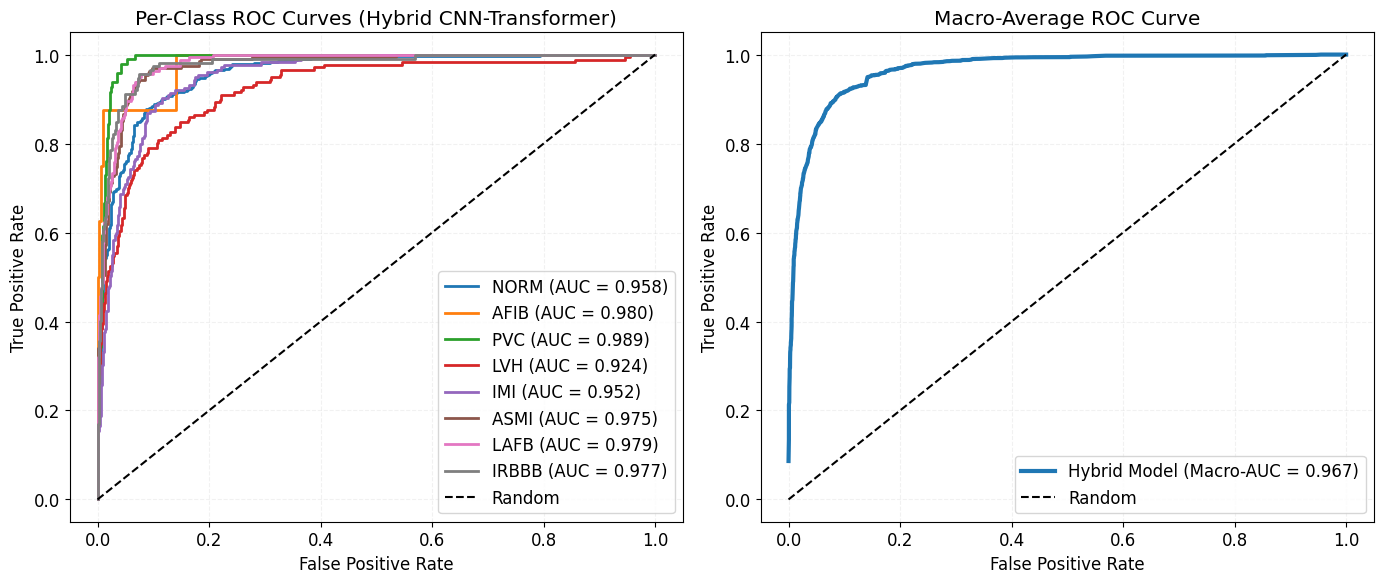


 ROC figure saved as: Hybrid_roc_curves.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
# FORCE CLEAN WHITE BACKGROUND
plt.style.use('default')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': True,
    'grid.color': 'lightgray',
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 12
})
# SAFETY CHECK
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

assert y_true.shape == y_pred.shape, "Mismatch between labels and predictions!"

# CLASS NAMES
class_names = ['NORM','AFIB','PVC','LVH','IMI','ASMI','LAFB','IRBBB']
n_classes = len(class_names)

# COMPUTE ROC FOR EACH CLASS
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# MACRO-AVERAGE ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

# Verify with sklearn
macro_auc_sklearn = roc_auc_score(y_true, y_pred, average='macro')

print(f"\nManual Macro-AUC:   {macro_auc:.4f}")
print(f"Sklearn Macro-AUC:  {macro_auc_sklearn:.4f}")

# PLOTTING
plt.rcParams.update({'font.size': 12})

plt.figure(figsize=(14,6))

# ---- Left: Per-Class ROC ----
plt.subplot(1,2,1)

for i in range(n_classes):
    plt.plot(
        fpr[i], 
        tpr[i], 
        lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0,1],[0,1],'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves (Hybrid CNN-Transformer)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# ---- Right: Macro ROC ----
plt.subplot(1,2,2)

plt.plot(
    all_fpr, 
    mean_tpr, 
    lw=3,
    label=f"Hybrid Model (Macro-AUC = {macro_auc:.3f})"
)

plt.plot([0,1],[0,1],'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save high-quality figure
#plt.savefig("hybrid_roc_curves.png", dpi=300, bbox_inches="tight")

plt.show()

print("\n ROC figure saved as: Hybrid_roc_curves.png")

In [17]:
wandb.finish()

epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
train_accuracy,▁▅▆▆▇▇▇▇▇▇▇████████████▇█▇▇█▇███████████
train_loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_auc,▂▃▇▅█▇▃█▅▄▂▄▂▇▇▅▆▇▆▆▇▆▃▆▇▃▃▁▆▂▅▂▇▄▃▁▁▂▂▁
epoch,100
train_accuracy,0.71896
train_loss,0.2011
val_auc,0.92718


In [12]:
print(type(model))
print(next(model.parameters()).device)
print(len(test_dataset))

<class '__main__.OptimizedHybrid'>
cuda:0
3576


In [13]:
#Add GRAD-CAM FUNCTION
import torch
import numpy as np

def gradcam_1d(model, input_signal, target_class, device):

    model.eval()

    # Ensure correct device
    input_signal = input_signal.to(device)

    # Ensure shape is (B, C, T)
    if input_signal.dim() == 2:   # (12, 1000)
        input_signal = input_signal.unsqueeze(0)

    assert input_signal.dim() == 3, \
        f"Expected (B, C, T), got {input_signal.shape}"

    gradients = []
    activations = []

    # Forward hook
    def forward_hook(module, input, output):
        activations.append(output)

    # Backward hook
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Attach hook to last CNN block
    handle_forward = model.cnn4.register_forward_hook(forward_hook)
    handle_backward = model.cnn4.register_full_backward_hook(backward_hook)

    # Forward pass
    output = model(input_signal)

    # Multi-label safe backward
    score = output[:, target_class]

    model.zero_grad()
    score.backward(torch.ones_like(score))

    # Extract gradients & activations
    grads = gradients[0].detach().cpu().numpy()[0]   # (C, T)
    acts = activations[0].detach().cpu().numpy()[0]  # (C, T)

    # Remove hooks
    handle_forward.remove()
    handle_backward.remove()

    # Global average pooling
    weights = np.mean(grads, axis=1)

    # Weighted combination
    cam = np.zeros(acts.shape[1])
    for i, w in enumerate(weights):
        cam += w * acts[i]

    # ReLU
    cam = np.maximum(cam, 0)

    # Normalize
    cam = cam / (np.max(cam) + 1e-8)

    return cam
    return cam

In [14]:
afib_index = target_labels.index("AFIB")

afib_samples = []

for i in range(len(test_dataset)):
    signal, label = test_dataset[i]

    # handle tensor labels safely
    if torch.is_tensor(label):
        label_val = label[afib_index].item()
    else:
        label_val = label[afib_index]

    if label_val == 1:
        afib_samples.append(signal)

    if len(afib_samples) == 50:
        break

print("Collected AFIB samples:", len(afib_samples))

Collected AFIB samples: 50


In [15]:
global_cams = []

for signal in afib_samples:

    cam = gradcam_1d(model, signal, afib_index, device)

    # Resize to 1000
    x_original = np.linspace(0, len(cam)-1, len(cam))
    x_target = np.linspace(0, len(cam)-1, 1000)

    cam_resized = np.interp(x_target, x_original, cam)

    global_cams.append(cam_resized)

global_cams = np.array(global_cams)

print(global_cams.shape)

(50, 1000)


In [16]:
mean_cam = global_cams.mean(axis=0)
print(mean_cam.shape)  # (1000,)

(1000,)


In [17]:
global_cams = np.array(global_cams)

print(type(global_cams))  # should show <class 'numpy.ndarray'>
print(global_cams.shape)  # should show (50, 1000)

<class 'numpy.ndarray'>
(50, 1000)


In [18]:
# Get AFIB class index
afib_index = target_labels.index("AFIB")

# Find one AFIB example
for i in range(len(test_dataset)):
    signal, label = test_dataset[i]

    if torch.is_tensor(label):
        label_val = label[afib_index].item()
    else:
        label_val = label[afib_index]

    if label_val == 1:
        sample_signal = signal
        print("Using AFIB sample at index:", i)
        break

Using AFIB sample at index: 12


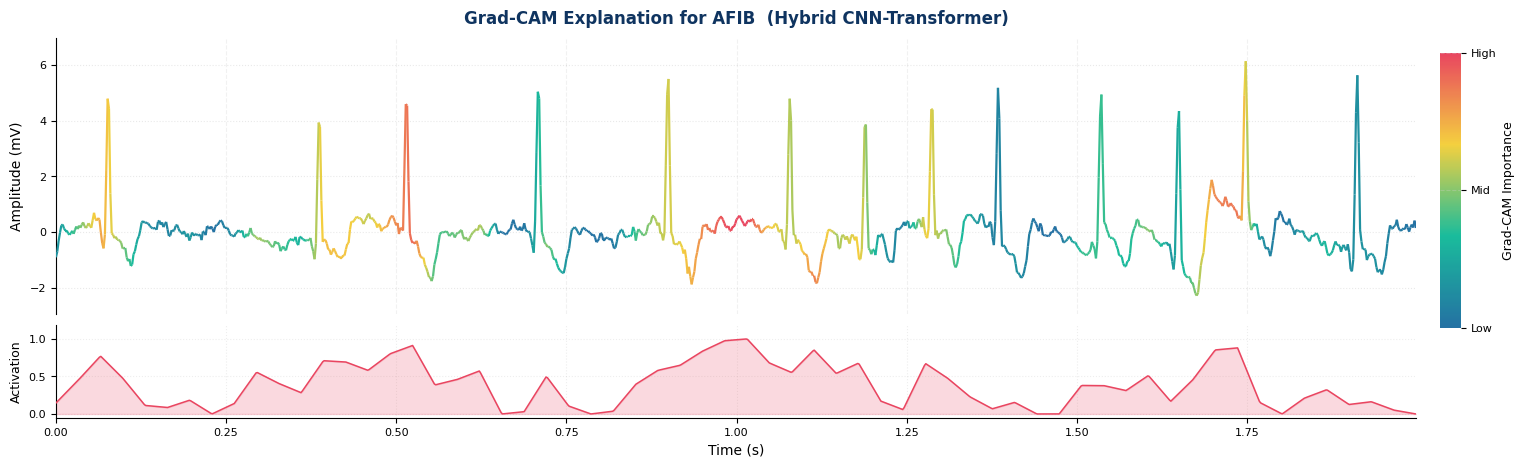

In [19]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
#── Same colormap as the grid plots ──────────────────────────────────────────
GRADCAM_CMAP = LinearSegmentedColormap.from_list(
    "thesis_gradcam",
    ["#2471A3", "#1ABC9C", "#F4D03F", "#E94560"],
    N=256,
)

# ── Your existing variables (no changes needed) ───────────────────────────────
lead_index  = 0
signal      = sample_signal[lead_index].numpy()
cam         = (cam_resized - cam_resized.min()) / (np.ptp(cam_resized) + 1e-8)
t           = np.arange(len(signal)) / 500   # seconds (change 500 to your fs)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5), facecolor="white")
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1],
                        hspace=0.06, left=0.07, right=0.92,
                        top=0.88, bottom=0.12)

# ── Top: ECG coloured by GradCAM ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("white")

points = np.array([t, signal]).T.reshape(-1, 1, 2)
segs   = np.concatenate([points[:-1], points[1:]], axis=1)
lc     = LineCollection(segs, cmap=GRADCAM_CMAP,
                        norm=plt.Normalize(0, 1),
                        linewidth=1.6, zorder=3)
lc.set_array(cam[:-1])
ax1.add_collection(lc)

ax1.set_xlim(t[0], t[-1])
ax1.set_ylim(signal.min() - 0.08 * np.ptp(signal),
             signal.max() + 0.10 * np.ptp(signal))

ax1.set_title("Grad-CAM Explanation for AFIB  (Hybrid CNN-Transformer)",
              fontsize=12, fontweight="bold", color="#0F3460", pad=10)
ax1.set_ylabel("Amplitude (mV)", fontsize=10)
ax1.set_xticklabels([])
ax1.tick_params(bottom=False, labelsize=8)
ax1.spines[["top", "right", "bottom"]].set_visible(False)
ax1.grid(axis="y", linestyle=":", alpha=0.25, color="#AAAAAA")

# Colorbar
cbar_ax = fig.add_axes([0.935, 0.30, 0.013, 0.55])
sm = plt.cm.ScalarMappable(cmap=GRADCAM_CMAP, norm=plt.Normalize(0, 1))
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label("Grad-CAM Importance", fontsize=9)
cb.set_ticks([0, 0.5, 1.0])
cb.set_ticklabels(["Low", "Mid", "High"])
cb.ax.tick_params(labelsize=8)
cb.outline.set_visible(False)

# ── Bottom: activation fill curve ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor("white")
ax2.plot(t, cam, color="#E94560", linewidth=1.1, zorder=3)
ax2.fill_between(t, cam, alpha=0.20, color="#E94560", zorder=2)
ax2.set_xlim(t[0], t[-1])
ax2.set_ylim(-0.05, 1.18)
ax2.set_xlabel("Time (s)", fontsize=10)
ax2.set_ylabel("Activation", fontsize=9)
ax2.tick_params(labelsize=8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(linestyle=":", alpha=0.2, color="#AAAAAA")

plt.savefig(
    "/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/gradcam_afib.pdf",
    dpi=300, bbox_inches="tight", facecolor="white",
)
plt.show()


In [20]:
#SHAP Interpretability
!pip install shap wfdb matplotlib numpy torch -q

In [21]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
import gc
torch.cuda.empty_cache()
gc.collect()

from tqdm import tqdm


In [22]:
model = model.cpu()
model.eval()

OptimizedHybrid(
  (cnn1): ResidualCNNBlock(
    (conv1): Conv1d(12, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv1d(12, 64, kernel_size=(1,), stride=(1,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (relu): ReLU(inplace=True)
  )
  (cnn2): ResidualCNNBlock(
    (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, a

In [23]:
afib_index = target_labels.index("AFIB")

afib_samples = []

for i in range(len(test_dataset)):
    signal, label = test_dataset[i]

    if label[afib_index] == 1:
        afib_samples.append(signal.numpy())

    if len(afib_samples) == 10:
        break

afib_samples = np.array(afib_samples)

print(afib_samples.shape)

(10, 12, 1000)


In [24]:
n_bins = 50
segment_length = 1000 // n_bins

signals_reduced = afib_samples.reshape(
    afib_samples.shape[0],
    12,
    n_bins,
    segment_length
).mean(axis=3)

print(signals_reduced.shape)

(10, 12, 50)


In [25]:
signals_flat = signals_reduced.reshape(signals_reduced.shape[0], -1)

print(signals_flat.shape)

(10, 600)


In [26]:
def model_predict(x):

    x = np.array(x)

    # reshape back to ECG
    x = x.reshape(x.shape[0], 12, 50)

    # expand bins back to 1000 timepoints
    x = np.repeat(x, 20, axis=2)

    x = torch.tensor(x).float()

    with torch.no_grad():
        preds = model(x).numpy()

    return preds

In [27]:
background = signals_flat[:5]

In [28]:
explainer = shap.KernelExplainer(model_predict, background)

In [29]:
shap_values = explainer.shap_values(
    signals_flat[:2],
    nsamples=50
)

100%|██████████| 2/2 [00:02<00:00,  1.33s/it]


In [30]:
afib_shap = shap_values[afib_index]

afib_shap = afib_shap.reshape(-1, 12, 50)

print(afib_shap.shape)

(8, 12, 50)


In [31]:
# convert SHAP to lead importance
lead_shap = np.mean(np.abs(afib_shap), axis=2)

print(lead_shap.shape)

(8, 12)


In [32]:
print("SHAP tensor:", afib_shap.shape)
print("Lead SHAP:", lead_shap.shape)

SHAP tensor: (8, 12, 50)
Lead SHAP: (8, 12)


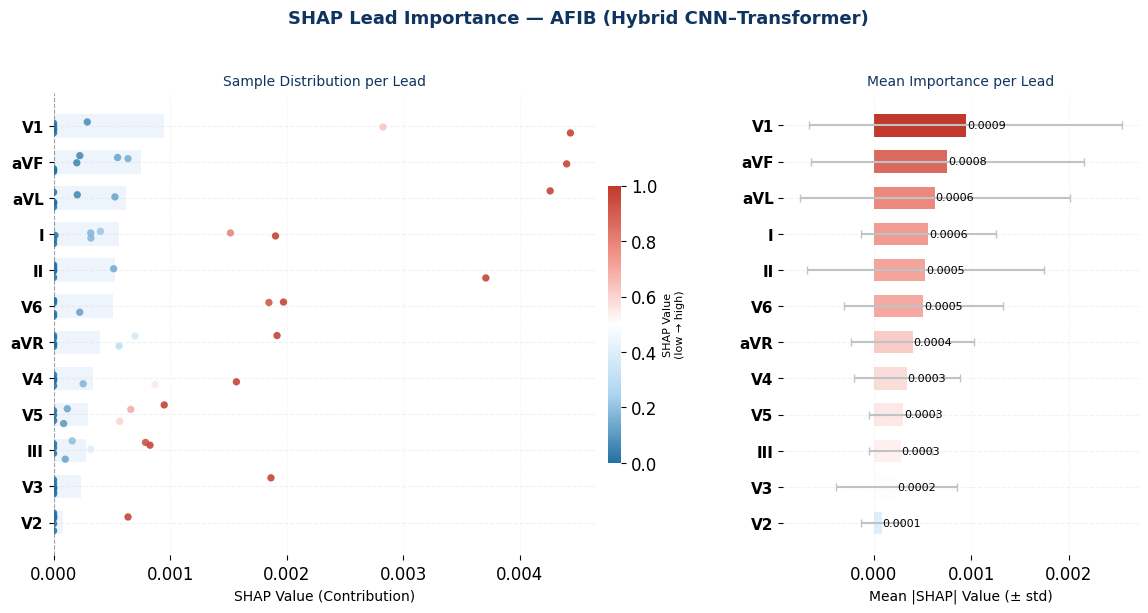

[✓] Saved → Figures/shap_lead_importance.pdf


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── Colormap ───────────────────────────────────────────────────────────────
SHAP_CMAP = LinearSegmentedColormap.from_list(
    "thesis_shap",
    ["#2471A3", "#AED6F1", "#FFFFFF", "#F1948A", "#C0392B"],
    N=256,
)

PALETTE = {
    "bg": "#FFFFFF",
    "text": "#1A1A2E",
    "blue": "#0F3460",
    "light": "#EAF2FB",
    "neutral": "#BDC3C7",
    "accent": "#E94560",
}

lead_names = ["I","II","III","aVR","aVL","aVF",
              "V1","V2","V3","V4","V5","V6"]

# ── Compute SHAP importance correctly ───────────────────────────────────────
lead_shap_abs = np.abs(lead_shap)

mean_importance = lead_shap_abs.mean(axis=0)
std_importance  = lead_shap_abs.std(axis=0)

# Sort leads by importance
order = np.argsort(mean_importance)
sorted_names = [lead_names[i] for i in order]

# ── Figure ──────────────────────────────────────────────────────────────────
fig, (ax_bee, ax_bar) = plt.subplots(
    1, 2,
    figsize=(14,6),
    gridspec_kw={"width_ratios":[1.6,1], "wspace":0.35},
    facecolor=PALETTE["bg"]
)

fig.suptitle(
    "SHAP Lead Importance — AFIB (Hybrid CNN–Transformer)",
    fontsize=13,
    fontweight="bold",
    color=PALETTE["blue"],
    y=1.02
)

# ────────────────────────────────────────────────────────────────────────────
# Beeswarm plot
# ────────────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

for plot_row, lead_i in enumerate(order):

    vals = lead_shap[:, lead_i]
    jitter = rng.uniform(-0.28,0.28,size=len(vals))

    norm_vals = (vals - vals.min()) / (np.ptp(vals) + 1e-8)
    colors = SHAP_CMAP(norm_vals)

    ax_bee.barh(
        plot_row,
        mean_importance[lead_i],
        height=0.65,
        color=PALETTE["light"],
        alpha=0.8,
        zorder=1
    )

    ax_bee.scatter(
        vals,
        plot_row + jitter,
        c=colors,
        s=28,
        alpha=0.85,
        linewidths=0,
        zorder=3
    )

ax_bee.axvline(0, color=PALETTE["text"], lw=0.8, ls="--", alpha=0.4)

ax_bee.set_yticks(range(12))
ax_bee.set_yticklabels(sorted_names, fontsize=11, fontweight="bold")
ax_bee.set_xlabel("SHAP Value (Contribution)", fontsize=10)
ax_bee.set_title("Sample Distribution per Lead", fontsize=10, color=PALETTE["blue"])
ax_bee.grid(axis="x", ls=":", alpha=0.25, color=PALETTE["neutral"])
ax_bee.spines[:].set_visible(False)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=SHAP_CMAP)
sm.set_array([])

cb = plt.colorbar(sm, ax=ax_bee, fraction=0.025, pad=0.02, shrink=0.6)
cb.set_label("SHAP Value\n(low → high)", fontsize=8)
cb.outline.set_visible(False)

# ────────────────────────────────────────────────────────────────────────────
# Bar chart
# ────────────────────────────────────────────────────────────────────────────
vals_sorted = mean_importance[order]
errs_sorted = std_importance[order]

norm_vals = (vals_sorted - vals_sorted.min()) / (np.ptp(vals_sorted) + 1e-8)
bar_colors = [SHAP_CMAP(0.4 + 0.6*v) for v in norm_vals]

bars = ax_bar.barh(
    range(12),
    vals_sorted,
    height=0.62,
    color=bar_colors,
    edgecolor="none",
    xerr=errs_sorted,
    error_kw=dict(ecolor=PALETTE["neutral"], capsize=3)
)

for bar, v in zip(bars, vals_sorted):
    ax_bar.text(
        v + vals_sorted.max()*0.01,
        bar.get_y()+bar.get_height()/2,
        f"{v:.4f}",
        va="center",
        fontsize=8
    )

ax_bar.set_yticks(range(12))
ax_bar.set_yticklabels(sorted_names, fontsize=11, fontweight="bold")
ax_bar.set_xlabel("Mean |SHAP| Value (± std)", fontsize=10)
ax_bar.set_title("Mean Importance per Lead", fontsize=10, color=PALETTE["blue"])
ax_bar.grid(axis="x", ls=":", alpha=0.25, color=PALETTE["neutral"])
ax_bar.spines[:].set_visible(False)

plt.tight_layout()

plt.savefig(
    "/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/shap_lead_importance.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("[✓] Saved → Figures/shap_lead_importance.pdf")

In [34]:
# CHECK DATA 
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_true sample row:", y_true[0])
print("y_pred sample row:", y_pred[0])

y_true shape: (3576, 8)
y_pred shape: (3576, 8)
y_true sample row: [1. 0. 0. 0. 0. 0. 0. 0.]
y_pred sample row: [0.5209392  0.4460102  0.4590808  0.7321486  0.5458554  0.34972537
 0.3879935  0.51345456]


In [35]:
# THRESHOLD OPTIMIZATION
from sklearn.metrics import f1_score
import numpy as np

best_thresholds = []
for i in range(y_true.shape[1]):
    best_thresh = 0.5
    best_f1 = 0.0
    for thresh in np.arange(0.1, 0.9, 0.05):
        y_pred_bin = (y_pred[:, i] >= thresh).astype(int)
        f1 = f1_score(y_true[:, i], y_pred_bin, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    best_thresholds.append(best_thresh)
    print(f"{target_labels[i]}: threshold={best_thresh:.2f} | F1={best_f1:.3f}")

print("Best thresholds:", best_thresholds)

NORM: threshold=0.35 | F1=0.825
AFIB: threshold=0.70 | F1=0.825
PVC: threshold=0.85 | F1=0.810
LVH: threshold=0.85 | F1=0.504
IMI: threshold=0.75 | F1=0.438
ASMI: threshold=0.75 | F1=0.646
LAFB: threshold=0.75 | F1=0.694
IRBBB: threshold=0.85 | F1=0.623
Best thresholds: [np.float64(0.3500000000000001), np.float64(0.7000000000000002), np.float64(0.8500000000000002), np.float64(0.8500000000000002), np.float64(0.7500000000000002), np.float64(0.7500000000000002), np.float64(0.7500000000000002), np.float64(0.8500000000000002)]


NORM: threshold=0.35 | F1=0.825
AFIB: threshold=0.70 | F1=0.825
PVC: threshold=0.85 | F1=0.810
LVH: threshold=0.85 | F1=0.504
IMI: threshold=0.75 | F1=0.438
ASMI: threshold=0.75 | F1=0.646
LAFB: threshold=0.75 | F1=0.694
IRBBB: threshold=0.85 | F1=0.623


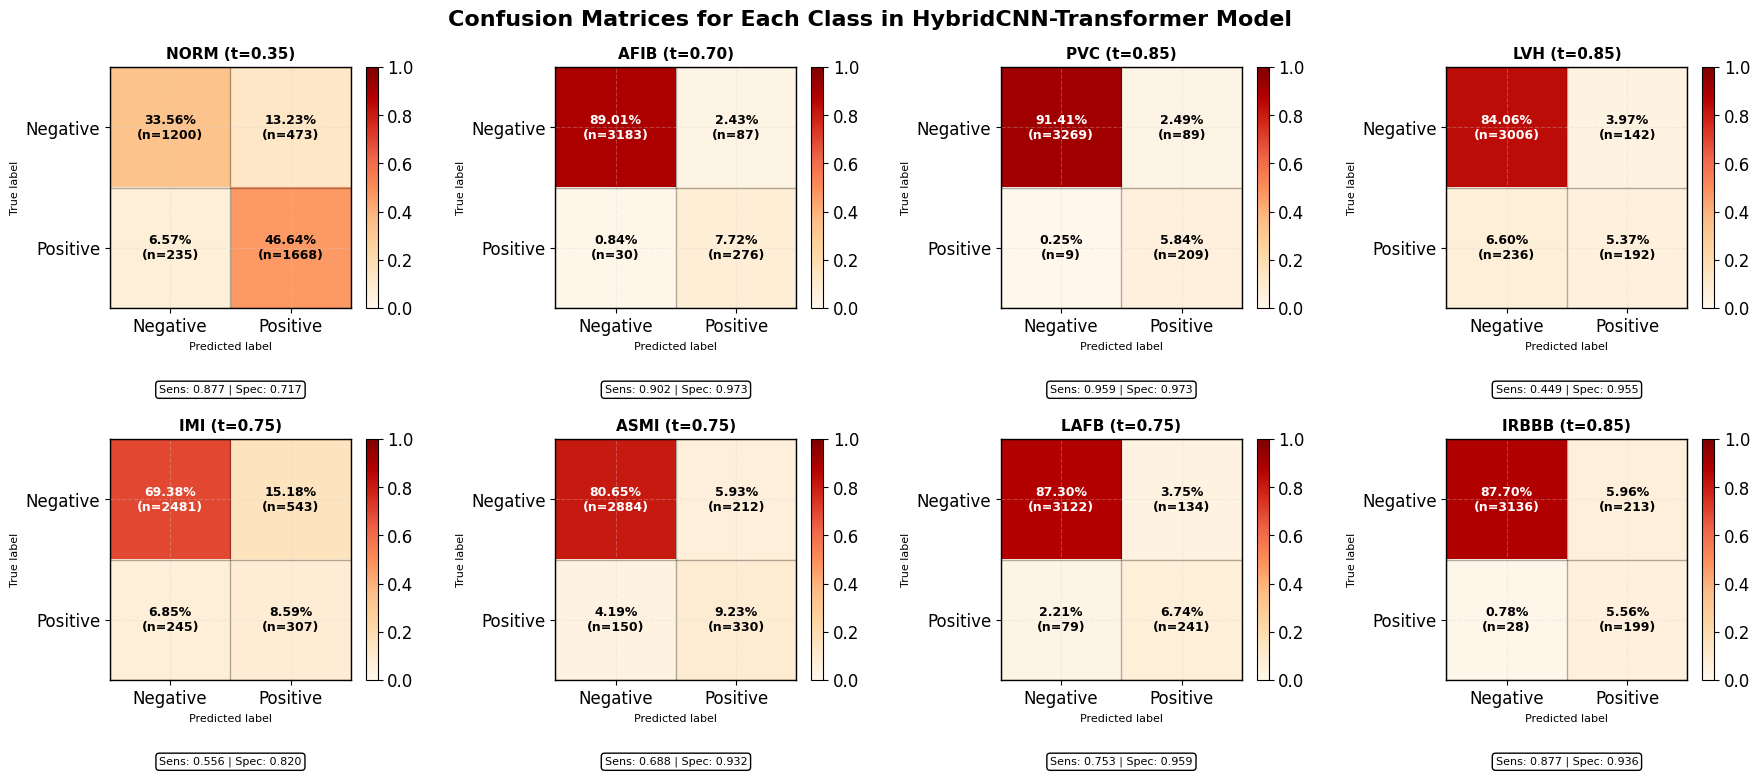

In [39]:
#CONFUSION MATRICES
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score

class_names = target_labels
n_classes = len(class_names)

# Find best threshold per class
best_thresholds = []
for i in range(y_true.shape[1]):
    best_thresh = 0.5
    best_f1 = 0.0
    for thresh in np.arange(0.1, 0.9, 0.05):
        y_pred_bin = (y_pred[:, i] >= thresh).astype(int)
        f1 = f1_score(y_true[:, i], y_pred_bin, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    best_thresholds.append(best_thresh)
    print(f"{class_names[i]}: threshold={best_thresh:.2f} | F1={best_f1:.3f}")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, ax in enumerate(axes.flat):

    # Multi-label: per-class binary with tuned threshold
    y_true_bin = y_true[:, i].astype(int)
    y_pred_bin = (y_pred[:, i] >= best_thresholds[i]).astype(int)

    cm = confusion_matrix(y_true_bin, y_pred_bin)
    TN, FP, FN, TP = cm.ravel()

    total = cm.sum()
    cm_prop = cm / total

    im = ax.imshow(cm_prop, cmap="OrRd", vmin=0, vmax=1)

    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    for r in range(2):
        for c in range(2):
            count = cm[r, c]
            percent = cm_prop[r, c] * 100
            color = "white" if cm_prop[r, c] > 0.5 else "black"
            ax.text(c, r, f"{percent:.2f}%\n(n={count})",
                    ha="center", va="center",
                    fontsize=9, fontweight="bold", color=color)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])
    ax.set_xlabel("Predicted label", fontsize=8)
    ax.set_ylabel("True label", fontsize=8)

    # Show threshold used in title
    ax.set_title(f"{class_names[i]} (t={best_thresholds[i]:.2f})",
                 fontsize=11, fontweight="bold")

    sens = TP / (TP + FN) if (TP + FN) > 0 else 0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0

    ax.text(0.5, -0.35,
            f"Sens: {sens:.3f} | Spec: {spec:.3f}",
            transform=ax.transAxes, ha="center", fontsize=8,
            bbox=dict(facecolor="white", edgecolor="black",
                      boxstyle="round,pad=0.3"))

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1)

    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Confusion Matrices for Each Class in HybridCNN-Transformer Model",
             fontsize=16, fontweight="bold")
plt.tight_layout()
#plt.savefig("confusion_matrix_hybrid.png", dpi=300, bbox_inches='tight')
plt.show()